In [3]:
import sys
print(sys.executable)

c:\Users\Anchal Pathania\Documents\poverty-mapping-ood\venv\Scripts\python.exe


In [2]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("Torch:", torch.__version__)
print("CUDA:", torch.cuda.is_available())

Torch: 2.12.0+cpu
CUDA: False


In [4]:
##Imports 
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np

from torchvision.models import convnext_tiny
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)
from scipy.stats import pearsonr

from data_loader import get_loaders

c:\Users\Anchal Pathania\Documents\poverty-mapping-ood\venv\Lib\site-packages\outdated\__init__.py:36: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import parse_version


In [5]:
###Device 
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print(device)

cpu


In [6]:
### ConvNeXt Model

import torch
import torch.nn as nn
from torchvision.models import convnext_tiny


class ConvNextPovertyModel(nn.Module):

    def __init__(self):

        super().__init__()

        # -------------------------
        # ConvNeXt Tiny Backbone
        # -------------------------
        self.backbone = convnext_tiny(
            weights="DEFAULT"
        )

        # Change first layer to 8 channels
        old_conv = self.backbone.features[0][0]

        self.backbone.features[0][0] = nn.Conv2d(
            in_channels=8,
            out_channels=old_conv.out_channels,
            kernel_size=old_conv.kernel_size,
            stride=old_conv.stride,
            padding=old_conv.padding,
            bias=False
        )

        # ConvNeXt feature size
        image_features = (
            self.backbone.classifier[2].in_features
        )

        # Remove classification head
        self.backbone.classifier = nn.Identity()

        # -------------------------
        # Metadata Branch
        # -------------------------
        self.metadata_net = nn.Sequential(

            nn.Linear(3, 16),
            nn.ReLU(),

            nn.Linear(16, 32),
            nn.ReLU()

        )

        # -------------------------
        # Combined Regressor
        # -------------------------
        self.regressor = nn.Sequential(

            nn.Linear(
                image_features + 32,
                256
            ),

            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(256, 64),
            nn.ReLU(),

            nn.Linear(64, 1)

        )

    def forward(self, image, metadata):

        image_features = self.backbone(
            image
        )

        metadata_features = self.metadata_net(
            metadata
        )

        combined = torch.cat(
            [image_features, metadata_features],
            dim=1
        )

        output = self.regressor(
            combined
        )

        return output


model = ConvNextPovertyModel()

print(model)

ConvNextPovertyModel(
  (backbone): ConvNeXt(
    (features): Sequential(
      (0): Conv2dNormActivation(
        (0): Conv2d(8, 96, kernel_size=(4, 4), stride=(4, 4), bias=False)
        (1): LayerNorm2d((96,), eps=1e-06, elementwise_affine=True, bias=True)
      )
      (1): Sequential(
        (0): CNBlock(
          (block): Sequential(
            (0): Conv2d(96, 96, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3), groups=96)
            (1): Permute()
            (2): LayerNorm((96,), eps=1e-06, elementwise_affine=True, bias=True)
            (3): Linear(in_features=96, out_features=384, bias=True)
            (4): GELU(approximate='none')
            (5): Linear(in_features=384, out_features=96, bias=True)
            (6): Permute()
          )
          (stochastic_depth): StochasticDepth(p=0.0, mode=row)
        )
        (1): CNBlock(
          (block): Sequential(
            (0): Conv2d(96, 96, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3), groups=96)
            (1)

In [7]:
###Loading the data
import os

os.chdir(r"C:\Users\Anchal Pathania\Documents\poverty-mapping-ood")

print(os.getcwd())

C:\Users\Anchal Pathania\Documents\poverty-mapping-ood


In [8]:
###Load Data

train_loader, val_loader, test_loader = get_loaders()

print(len(train_loader))
print(len(val_loader))
print(len(test_loader))

307
123
124


c:\Users\Anchal Pathania\Documents\poverty-mapping-ood\venv\Lib\site-packages\wilds\datasets\poverty_dataset.py:218: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\torch\csrc\utils\tensor_numpy.cpp:219.)
  self._y_array = torch.from_numpy(np.asarray(self.metadata['wealthpooled'])[:, np.newaxis]).float()


In [9]:
import torch
import torch.nn as nn
from torchvision.models import convnext_tiny


class ConvNextPovertyModel(nn.Module):

    def __init__(self):

        super().__init__()

        # ConvNeXt Tiny Backbone
        self.backbone = convnext_tiny(
            weights="DEFAULT"
        )

        # Change first layer to 8 channels
        old_conv = self.backbone.features[0][0]

        self.backbone.features[0][0] = nn.Conv2d(
            in_channels=8,
            out_channels=old_conv.out_channels,
            kernel_size=old_conv.kernel_size,
            stride=old_conv.stride,
            padding=old_conv.padding,
            bias=False
        )

        # ConvNeXt Tiny final feature dimension
        image_features = 768

        # Metadata Branch
        self.metadata_net = nn.Sequential(

            nn.Linear(3, 16),
            nn.ReLU(),

            nn.Linear(16, 32),
            nn.ReLU()

        )

        # Combined Regressor
        self.regressor = nn.Sequential(

            nn.Linear(
                image_features + 32,
                256
            ),

            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(256, 64),
            nn.ReLU(),

            nn.Linear(64, 1)

        )

    def forward(self, image, metadata):

        # Extract ConvNeXt features
        image_features = self.backbone.features(
            image
        )

        # Global Average Pooling
        image_features = image_features.mean(
            dim=(2, 3)
        )

        metadata_features = self.metadata_net(
            metadata
        )

        combined = torch.cat(
            [image_features, metadata_features],
            dim=1
        )

        output = self.regressor(
            combined
        )

        return output

In [10]:
# Test Model

x, y, metadata = next(iter(train_loader))

x = x.to(device)

metadata = metadata[:, [0, 2, 3]]
metadata = metadata.float().to(device)

model = ConvNextPovertyModel().to(device)

with torch.no_grad():

    out = model(x, metadata)

print("Output shape:", out.shape)

Output shape: torch.Size([32, 1])


In [ ]:
    ### Train ConvNeXt Tiny + Metadata

    import torch.nn as nn
    import torch.optim as optim

    device = torch.device(
        "cuda" if torch.cuda.is_available() else "cpu"
    )

    print("Device:", device)

    model = ConvNextPovertyModel().to(device)

    criterion = nn.MSELoss()

    optimizer = optim.AdamW(
        model.parameters(),
        lr=1e-4,
        weight_decay=1e-4
    )

    scheduler = optim.lr_scheduler.CosineAnnealingLR(
        optimizer,
        T_max=20
    )

    PATIENCE = 5
    MAX_EPOCHS = 50

    best_loss = float("inf")
    patience_counter = 0

    train_losses = []
    val_losses = []

    for epoch in range(MAX_EPOCHS):

        # =====================
        # TRAIN
        # =====================

        model.train()

        train_loss = 0.0

        for x, y, metadata in train_loader:

            x = x.to(device)

            y = y.float().squeeze().to(device)

            # Remove wealthpooled metadata
            metadata = metadata[:, [0, 2, 3]]

            metadata = metadata.float().to(device)

            optimizer.zero_grad()

            preds = model(
                x,
                metadata
            ).squeeze()

            loss = criterion(
                preds,
                y
            )

            loss.backward()

            optimizer.step()

            train_loss += loss.item()

        train_loss /= len(train_loader)

        # =====================
        # VALIDATION
        # =====================

        model.eval()

        val_loss = 0.0

        with torch.no_grad():

            for x, y, metadata in val_loader:

                x = x.to(device)

                y = y.float().squeeze().to(device)

                metadata = metadata[:, [0, 2, 3]]

                metadata = metadata.float().to(device)

                preds = model(
                    x,
                    metadata
                ).squeeze()

                loss = criterion(
                    preds,
                    y
                )

                val_loss += loss.item()

        val_loss /= len(val_loader)

        scheduler.step()

        train_losses.append(train_loss)
        val_losses.append(val_loss)

        print(
            f"Epoch [{epoch+1}/{MAX_EPOCHS}] | "
            f"Train Loss: {train_loss:.4f} | "
            f"Val Loss: {val_loss:.4f}"
        )

        # =====================
        # SAVE BEST MODEL
        # =====================

        if val_loss < best_loss:

            best_loss = val_loss

            torch.save(
                model.state_dict(),
                "best_convnext_tiny.pt"
            )

            print("Best model saved!")

            patience_counter = 0

        else:

            patience_counter += 1

        # =====================
        # EARLY STOPPING
        # =====================

        if patience_counter >= PATIENCE:

            print(
                f"\nEarly stopping triggered after "
                f"{epoch+1} epochs."
            )

            break

    print("\nTraining Complete!")
    print("Best Validation Loss:", best_loss)

Device: cpu
Epoch [1/50] | Train Loss: 0.2843 | Val Loss: 0.1741
Best model saved!
Epoch [2/50] | Train Loss: 0.2145 | Val Loss: 0.1953
Epoch [3/50] | Train Loss: 0.1901 | Val Loss: 0.1610
Best model saved!
Epoch [4/50] | Train Loss: 0.1680 | Val Loss: 0.1571
Best model saved!
Epoch [5/50] | Train Loss: 0.1445 | Val Loss: 0.1769
Epoch [6/50] | Train Loss: 0.1183 | Val Loss: 0.1702
Epoch [7/50] | Train Loss: 0.0924 | Val Loss: 0.2049
Epoch [8/50] | Train Loss: 0.0676 | Val Loss: 0.2924
Epoch [9/50] | Train Loss: 0.0511 | Val Loss: 0.1669

Early stopping triggered after 9 epochs.

Training Complete!
Best Validation Loss: 0.15705133238580168


Model loaded successfully!

===== TEST RESULTS =====
MAE       : 0.3619
RMSE      : 0.4661
R²        : 0.7190
Pearson r : 0.8561


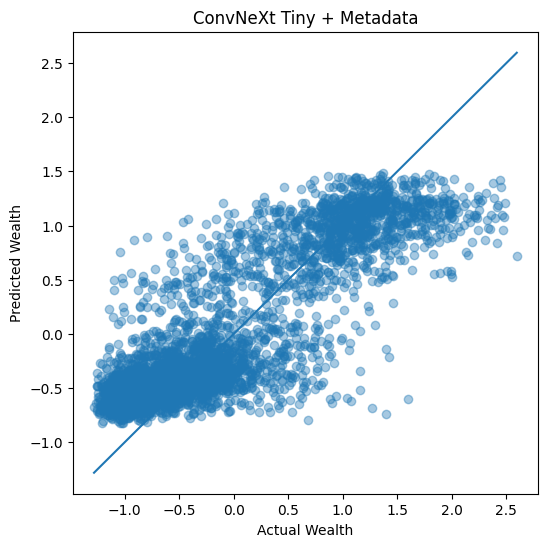

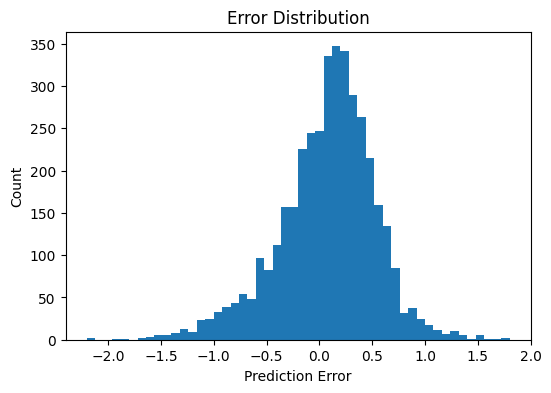

In [13]:
import torch
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from scipy.stats import pearsonr

# --------------------
# Load best model
# --------------------

model.load_state_dict(
    torch.load(
        "best_convnext_tiny.pt",
        map_location=device
    )
)

model.eval()

print("Model loaded successfully!")

# --------------------
# Evaluate
# --------------------

preds = []
targets = []

with torch.no_grad():

    for x, y, metadata in test_loader:

        x = x.to(device)

        # IMPORTANT
        metadata = metadata[:, [0, 2, 3]]

        metadata = metadata.float().to(device)

        outputs = model(
            x,
            metadata
        )

        preds.extend(
            outputs.squeeze().cpu().numpy()
        )

        targets.extend(
            y.squeeze().cpu().numpy()
        )

preds = np.array(preds)
targets = np.array(targets)

# --------------------
# Metrics
# --------------------

mae = mean_absolute_error(
    targets,
    preds
)

rmse = np.sqrt(
    mean_squared_error(
        targets,
        preds
    )
)

r2 = r2_score(
    targets,
    preds
)

pearson_r, _ = pearsonr(
    targets,
    preds
)

print("\n===== TEST RESULTS =====")

print(f"MAE       : {mae:.4f}")
print(f"RMSE      : {rmse:.4f}")
print(f"R²        : {r2:.4f}")
print(f"Pearson r : {pearson_r:.4f}")

# --------------------
# Scatter Plot
# --------------------

plt.figure(figsize=(6,6))

plt.scatter(
    targets,
    preds,
    alpha=0.4
)

plt.plot(
    [targets.min(), targets.max()],
    [targets.min(), targets.max()]
)

plt.xlabel("Actual Wealth")
plt.ylabel("Predicted Wealth")
plt.title("ConvNeXt Tiny + Metadata")

plt.show()

# --------------------
# Error Histogram
# --------------------

errors = preds - targets

plt.figure(figsize=(6,4))

plt.hist(
    errors,
    bins=50
)

plt.xlabel("Prediction Error")
plt.ylabel("Count")
plt.title("Error Distribution")

plt.show()